In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
import matplotlib.pyplot as mp
import tensorflow as tf
import tensorflow_datasets as td
import keras
import os
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
import numpy as np
from keras.models import load_model
from keras.preprocessing import image

In [12]:
df,info = td.load('horses_or_humans',with_info = True,as_supervised = True)

In [13]:
class_names = info.features['label'].names
class_names

['horses', 'humans']

In [4]:
info.supervised_keys,info.splits

(('image', 'label'),
 {'train': <SplitInfo num_examples=1027, num_shards=2>,
  'test': <SplitInfo num_examples=256, num_shards=1>})

In [5]:
df['train']

<_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
for i,e in enumerate(df['train']):
    img,label = e
    save_dir = fr"G:\Coding Languages\Artificial Intelligence\Datasets\Horse Or Human\train\{class_names[label]}"
    os.makedirs(save_dir,exist_ok = True)
    Fpath = save_dir + '/' + class_names[label] + "_" + str(i) + ".jpg"
    
    keras.preprocessing.image.save_img(Fpath,img.numpy())

In [ ]:
for i,e in enumerate(df['test']):
    img,label = e
    save_dir = fr"G:\Coding Languages\Artificial Intelligence\Datasets\Horse Or Human\test\{class_names[label]}"
    os.makedirs(save_dir,exist_ok = True)
    Fpath = save_dir + "/" + class_names[label] + "_" + str(i) + ".jpg"
    keras.preprocessing.image.save_img(Fpath,img.numpy())

In [ ]:
ImgSize = (300,300)
BatchSize = 32
TrainDir = r"G:\Coding Languages\Artificial Intelligence\Datasets\Horse Or Human\train"
TrainDataGen = ImageDataGenerator(rescale = 1/255)
TrainGen = TrainDataGen.flow_from_directory(TrainDir,target_size = ImgSize,batch_size = BatchSize,class_mode = 'binary')

TestDir = r"G:\Coding Languages\Artificial Intelligence\Datasets\Horse Or Human\test"
TestDataGen = ImageDataGenerator(rescale = 1/255)
TestGen = TestDataGen.flow_from_directory(TestDir,target_size = ImgSize, batch_size = BatchSize,class_mode = 'binary')

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


In [16]:
TrainGen.class_indices,TrainGen.class_mode

({'horses': 0, 'humans': 1}, 'binary')

In [17]:
TrainGen.classes,TrainGen.filenames[:5],TrainGen.samples

(array([0, 0, 0, ..., 1, 1, 1], dtype=int32),
 ['horses\\horses_0.jpg',
  'horses\\horses_1.jpg',
  'horses\\horses_1000.jpg',
  'horses\\horses_1004.jpg',
  'horses\\horses_1005.jpg'],
 1027)

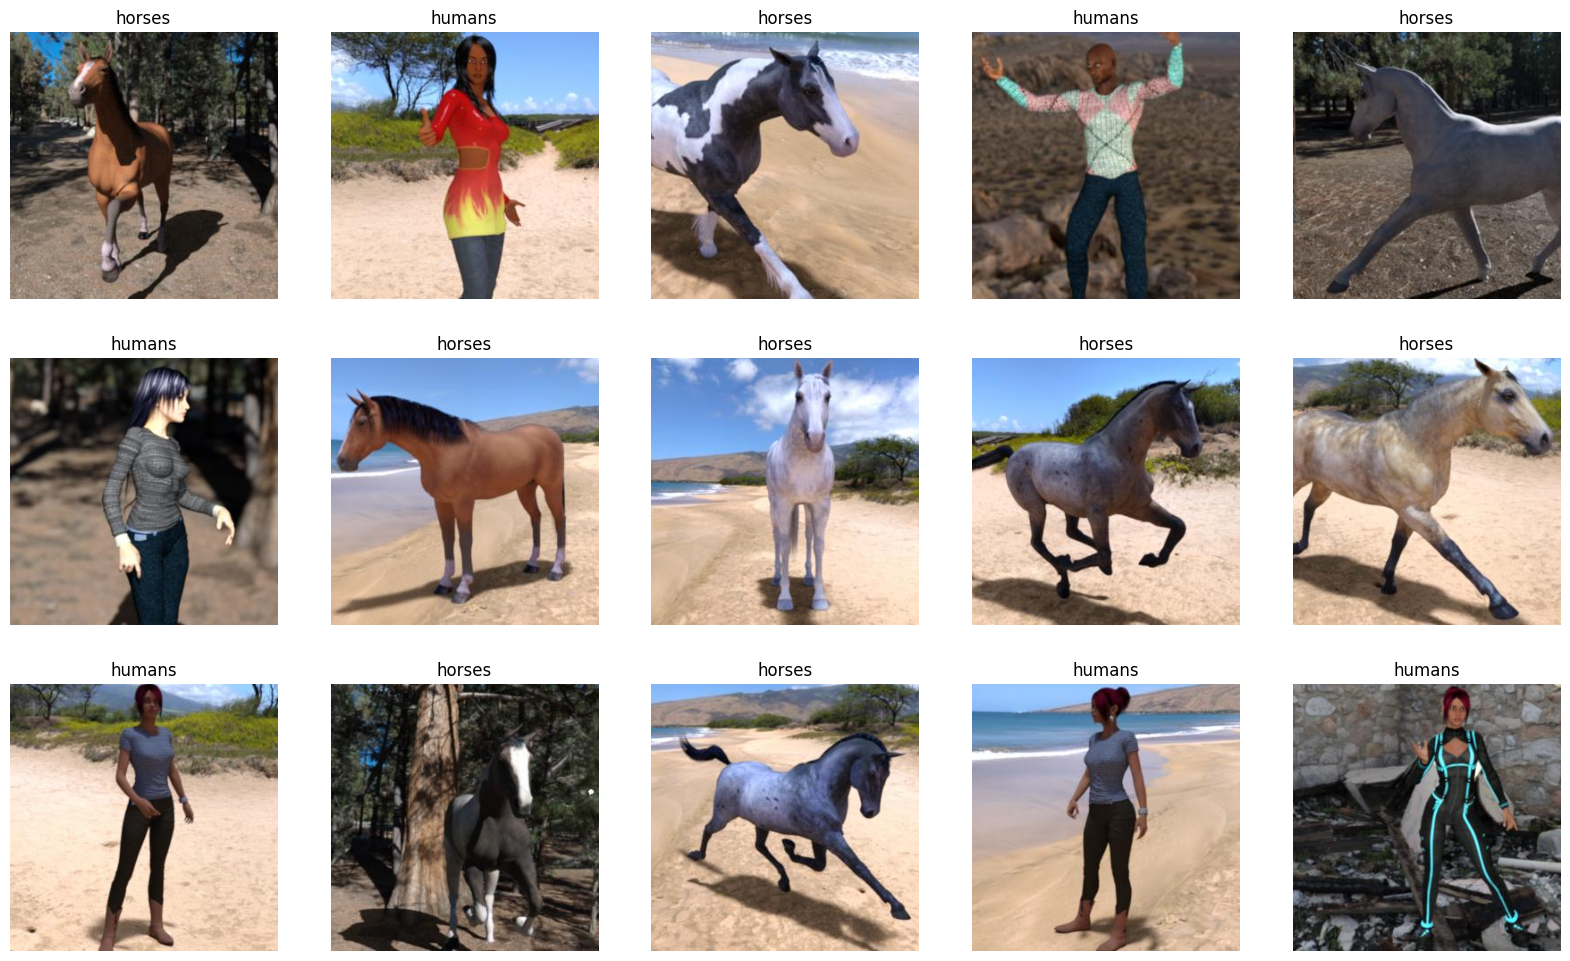

In [ ]:
nrows = 3
ncols = 5

TrainPath = r"G:\Coding Languages\Artificial Intelligence\Datasets\Horse Or Human\train"
fig = mp.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

NextBatch = next(TrainGen)
for i in range(0,nrows * ncols):
    ax = mp.subplot(nrows,ncols,i + 1)
    ax.axis('Off')
    mp.imshow(NextBatch[0][i])
    ClassIndex = NextBatch[1][i]
    mp.title(class_names[int(ClassIndex)])
mp.show()

In [23]:
def GetModel():

    Model = Sequential()
    Model.add(Conv2D(filters = 128,kernel_size = (3,3), activation = 'relu',input_shape = (300,300,3)))
    Model.add(MaxPooling2D(pool_size = (5,5)))

    Model.add(Conv2D(filters = 256, kernel_size = (3,3), activation = 'relu'))
    Model.add(MaxPooling2D(pool_size = (5,5)))

    Model.add(Conv2D(filters = 512, kernel_size = (3,3), activation = 'relu'))
    Model.add(MaxPooling2D(pool_size = (3,3),strides = 2))

    Model.add(Conv2D(filters = 512, kernel_size = (3,3), activation = 'relu'))

    Model.add(Flatten())
    Model.add(Dense(512, activation = 'relu'))

    Model.add(Dense(1, activation = 'sigmoid'))

    return Model

In [24]:
Model = GetModel()

g:\Applications\Python 3.10.11\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,888,321 (18.65 MB)

 Trainable params: 4,888,321 (18.65 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
Model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2D name=conv2d_3, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>]

In [28]:
weights, biases = Model.layers[0].get_weights()

In [30]:
len(biases),len(weights)

(128, 3)

In [34]:
Model.layers[1].get_weights()

[]

In [35]:
Model.compile(optimizer = 'Adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

In [37]:
History = Model.fit(TrainGen,epochs = 5, validation_data = TestGen)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.9963 - loss: 0.0141 - val_accuracy: 0.8242 - val_loss: 1.7430
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 122s 4s/step - accuracy: 0.9887 - loss: 0.0295 - val_accuracy: 0.8438 - val_loss: 1.8011
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.9780 - loss: 0.0738 - val_accuracy: 0.8594 - val_loss: 1.1632
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.9933 - loss: 0.0258 - val_accuracy: 0.8867 - val_loss: 1.4437
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.9894 - loss: 0.0259 - val_accuracy: 0.8242 - val_loss: 1.8587


In [40]:
History.history

{'accuracy': [0.9912366271018982,
  0.9883154630661011,
  0.9795520901679993,
  0.9941577315330505,
  0.9892891645431519],
 'loss': [0.032375987619161606,
  0.028543325141072273,
  0.06447009742259979,
  0.022669635713100433,
  0.032076526433229446],
 'val_accuracy': [0.82421875, 0.84375, 0.859375, 0.88671875, 0.82421875],
 'val_loss': [1.7430131435394287,
  1.8011399507522583,
  1.1631710529327393,
  1.443708062171936,
  1.8586652278900146]}

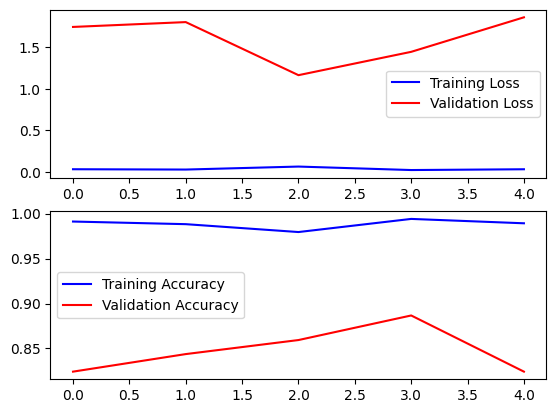

In [42]:
fix,ax = mp.subplots(2,1)
ax[0].plot(History.history['loss'],color = 'b', label = 'Training Loss')
ax[0].plot(History.history['val_loss'],color = 'r', label = 'Validation Loss')
ax[0].legend()

ax[1].plot(History.history['accuracy'],color = 'b', label = 'Training Accuracy')
ax[1].plot(History.history['val_accuracy'],color = 'r',label = 'Validation Accuracy')
ax[1].legend()

In [43]:
Model.save('Horse OR Human.h5')

In [45]:
LoadModel = load_model('Horse OR Human.h5')

In [47]:
img = image.load_img(r"G:\Coding Languages\Artificial Intelligence\Datasets\Horse Or Human\test\humans\humans_3.jpg")
TargetSize = (300,300)
img = image.img_to_array(img)
img = np.expand_dims(img,axis = 0)
img = img/255

prediction = LoadModel(img)
print(prediction)
TH = 0.5
ClassPredicted = int(prediction[0][0] > TH)
ClassIndices = TrainGen.class_indices
Labels = {v:k for k,v in ClassIndices.items()}
print("The Image Is Of A:",Labels[ClassPredicted])

tf.Tensor([[1.]], shape=(1, 1), dtype=float32)
The Image Is Of A: humans
